# 03 — Results: Strategy Comparison, Volatility Forecasting, and What Actually Held Up

This notebook reads the pre-computed outputs of `scripts/run_backtests.py` and
`scripts/run_vol_model.py` (run those first if `results/tables/` is empty) and
tells the honest version of the story: what worked, what didn't, and what
wasn't statistically distinguishable from noise.


In [1]:
import sys
sys.path.insert(0, "../src")

import pandas as pd
import json
from pathlib import Path
from IPython.display import Image, display

from riskengine.config import TABLES, RESULTS, FIGURES

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 160)


## 1. Six strategies, one walk-forward test

In [2]:
comparison = pd.read_csv(TABLES / "strategy_comparison.csv", index_col=0)
comparison.round(3)


,CAGR,Ann.Vol,Sharpe,Sortino,MaxDD,Calmar,Beta,Alpha,InfoRatio,HitRate,AvgTurnover,CostDrag,Ann.Return,Ulcer,Skew,Kurtosis,Treynor
equal_weight,0.220,0.192,0.805,1.092,-0.343,0.642,0.919,0.091,0.816,0.539,0.245,0.004,0.218,0.096,-1.189,15.434,0.166
inverse_vol,0.207,0.185,0.770,1.048,-0.331,0.624,0.889,0.081,0.730,0.528,0.248,0.004,0.205,0.095,-1.133,15.972,0.158
min_variance,0.186,0.165,0.737,1.025,-0.308,0.605,0.753,0.069,0.488,0.640,0.325,0.005,0.184,0.094,-0.714,16.726,0.159
risk_parity,0.212,0.182,0.802,1.092,-0.333,0.635,0.874,0.085,0.768,0.573,0.252,0.004,0.209,0.095,-1.095,15.662,0.165
max_sharpe,0.259,0.211,0.899,1.247,-0.354,0.733,0.946,0.125,0.924,0.607,0.280,0.004,0.253,0.103,-0.765,11.565,0.199
score_based,0.251,0.222,0.838,1.151,-0.348,0.722,0.993,0.118,0.852,0.584,0.272,0.004,0.249,0.100,-1.031,14.304,0.186
min_variance (sample cov),0.186,0.165,0.733,1.020,-0.307,0.604,0.751,0.069,0.479,0.640,0.330,0.005,0.184,0.094,-0.690,16.635,0.158
Nifty 50 (buy & hold),0.124,0.176,0.393,0.534,-0.384,0.322,1.000,0.000,NaN,0.000,NaN,NaN,0.132,0.077,-1.126,18.482,0.067


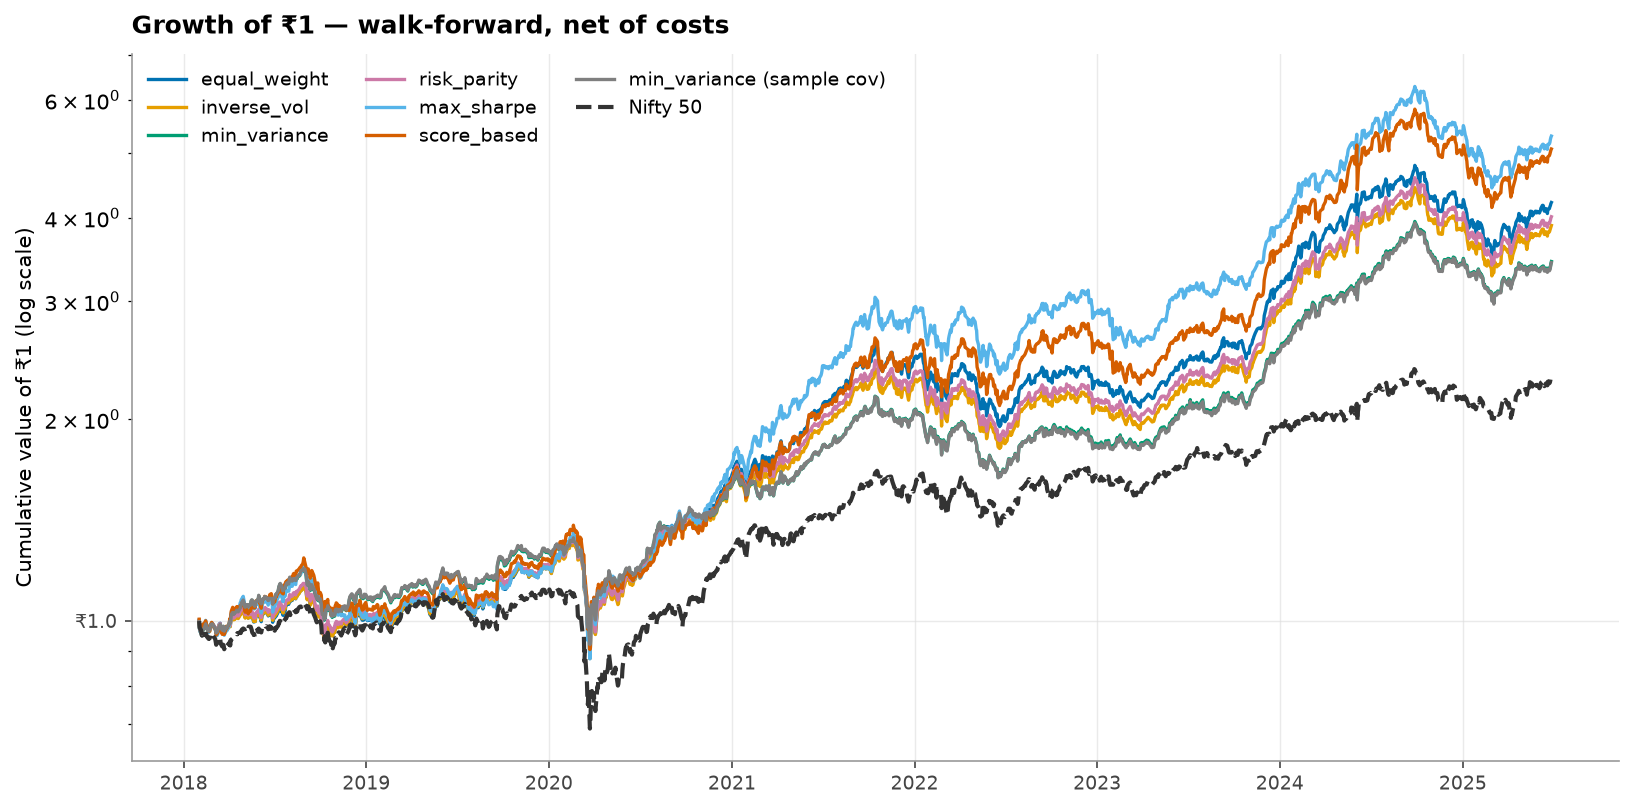

In [3]:
display(Image(filename=str(FIGURES / "equity_curves.png")))


**Headline observation**: every strategy — including plain equal-weight — beats the Nifty 50 by a wide absolute margin. Before concluding the stock-picking added value, read `docs/methodology.md#1-universe-and-survivorship-bias` — a meaningful share of this gap is the universe (curated large/mid-caps), not the allocation method. The comparison that actually isolates the allocation method's contribution is strategy-vs-strategy, all drawn from the identical universe.

## 2. Is any strategy significantly better than equal-weight?

In [4]:
sig = pd.read_csv(TABLES / "significance_tests.csv", index_col=0)
sig


,sharpe_diff,ci_95_low,ci_95_high,bootstrap_p,active_t_stat,active_p,PSR,DSR,significant_5pct
strategy,,,,,,,,,
equal_weight,0.412,-0.026,0.843,0.064,2.22,0.026,0.982,0.774,False
inverse_vol,0.377,-0.050,0.806,0.091,1.98,0.047,0.978,0.747,False
min_variance,0.344,-0.102,0.814,0.171,1.30,0.195,0.974,0.720,False
risk_parity,0.408,-0.020,0.857,0.065,2.07,0.038,0.982,0.772,False
max_sharpe,0.505,0.014,0.986,0.042,2.48,0.013,0.991,0.842,True
score_based,0.445,-0.044,0.914,0.070,2.37,0.018,0.986,0.800,False
min_variance (sample cov),0.340,-0.108,0.807,0.177,1.27,0.203,0.973,0.717,False


Bootstrap 95% CI on (strategy Sharpe − Nifty Sharpe), via a stationary block bootstrap that respects daily-return autocorrelation. Only rows where `ci_95_low > 0` are strategies whose outperformance survives resampling uncertainty.

Read the `significant_5pct` column plainly: most strategies show a positive point estimate but a CI that still straddles zero. That is the honest outcome of testing six variants against ~7.5 years of data — it is not a failure of the project, it's what rigorous testing is supposed to surface instead of hiding.

In [5]:
best_info = json.loads((TABLES / "best_vs_equalweight.json").read_text())
print(f"Best strategy by Sharpe: {best_info['best']}")
print(f"  vs equal-weight: diff={best_info['diff']:.3f}, 95% CI=[{best_info['ci_low']:.3f}, {best_info['ci_high']:.3f}], p={best_info['p_value']:.3f}")


Best strategy by Sharpe: max_sharpe
  vs equal-weight: diff=0.094, 95% CI=[-0.124, 0.307], p=0.407


## 3. Stress windows

In [6]:
stress = pd.read_csv(TABLES / "stress_tests.csv", index_col=0)
stress.style.format("{:.1%}")


,equal_weight,min_variance,score_based,Nifty 50
COVID crash (Feb-Mar 2020),-33.3%,-29.9%,-33.6%,-36.5%
COVID recovery (Apr-Dec 2020),86.7%,72.7%,78.3%,83.7%
2022 rate shock (Jan-Jun 2022),-20.2%,-20.6%,-17.5%,-11.9%
Oct 2021 - Mar 2023 (flat market),-16.8%,-14.4%,-11.1%,-6.0%
2024-25 correction (Sep 24-Feb 25),-25.8%,-23.2%,-27.9%,-15.6%


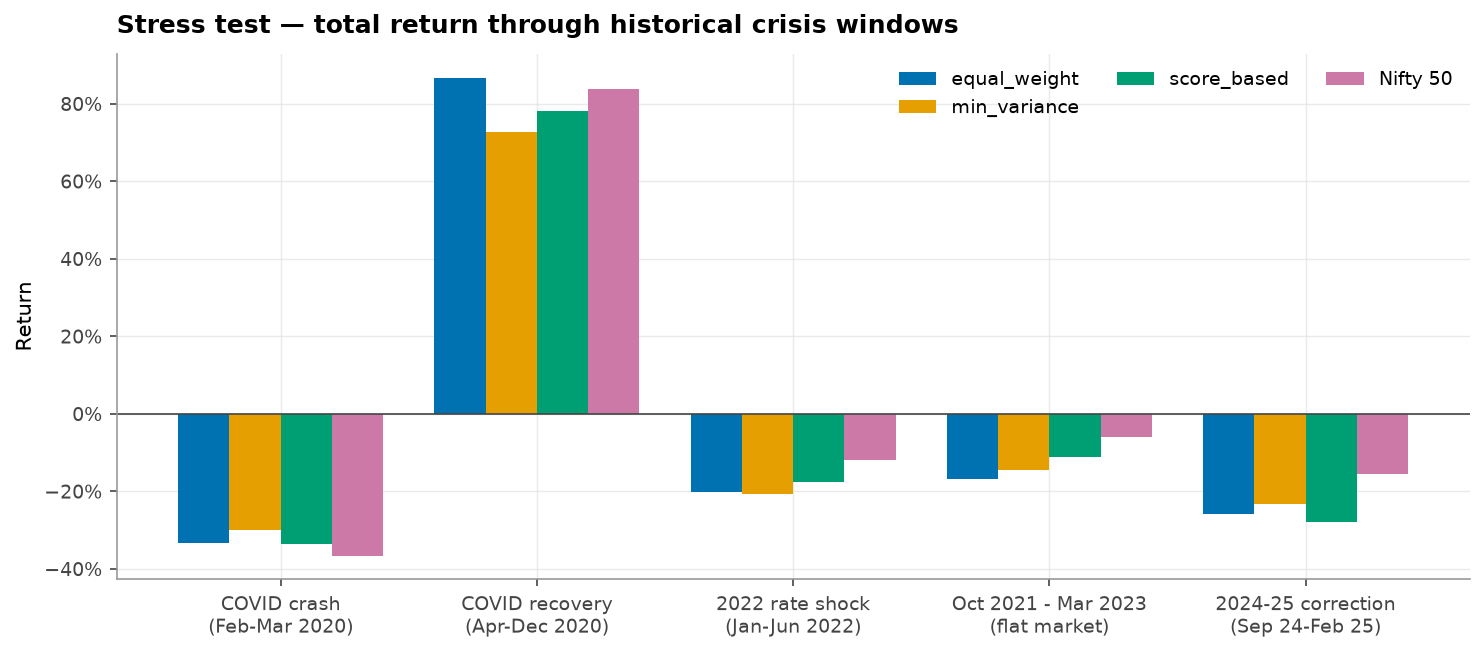

In [7]:
display(Image(filename=str(FIGURES / "stress_tests.png")))


A second honest finding worth sitting with: in several of these windows — particularly the macro-driven 2022 rate shock and the 2024-25 correction — the equity-only, long-only strategies underperformed the Nifty 50, not just their own past returns. A concentrated 15-25 stock book has less diversification than a 50-stock index during a broad, sector-agnostic drawdown, and that shows up exactly where you'd expect it to.

## 4. Volatility forecasting — LightGBM vs. EWMA vs. GARCH

In [8]:
vol_cmp = pd.read_csv(TABLES / "vol_model_comparison.csv", index_col=0)
vol_cmp


,RMSE,MAE,QLIKE,R2,n,RMSE_vs_EWMA_%,QLIKE_vs_EWMA_%
Random walk (RV21),0.15377,0.10249,0.41257,0.01489,10590.0,7.33418,24.18681
EWMA(0.94),0.14327,0.09451,0.33221,0.14492,10590.0,0.00000,0.00000
Hybrid (RV21+RV252)/2,0.13352,0.08814,0.28376,0.25729,10590.0,-6.80223,-14.58678
LightGBM,0.12811,0.07957,0.28330,0.31626,10590.0,-10.57860,-14.72255
"GARCH(1,1)-t",0.14954,0.09939,0.29884,0.06837,10590.0,4.38030,-10.04750


In [9]:
dm = pd.read_csv(TABLES / "vol_dm_tests.csv")
dm


,comparison,loss,DM_stat,p_value,n,verdict
0,LightGBM vs Random walk (RV21),QLIKE,-10.678,0.0000,10658,LightGBM better (5%)
1,LightGBM vs Random walk (RV21),MSE,-9.065,0.0000,10658,LightGBM better (5%)
2,LightGBM vs EWMA(0.94),QLIKE,-4.460,0.0000,10658,LightGBM better (5%)
3,LightGBM vs EWMA(0.94),MSE,-6.940,0.0000,10658,LightGBM better (5%)
4,"LightGBM vs GARCH(1,1)-t",QLIKE,-1.402,0.1609,10590,no significant difference
5,"LightGBM vs GARCH(1,1)-t",MSE,-8.608,0.0000,10590,LightGBM better (5%)


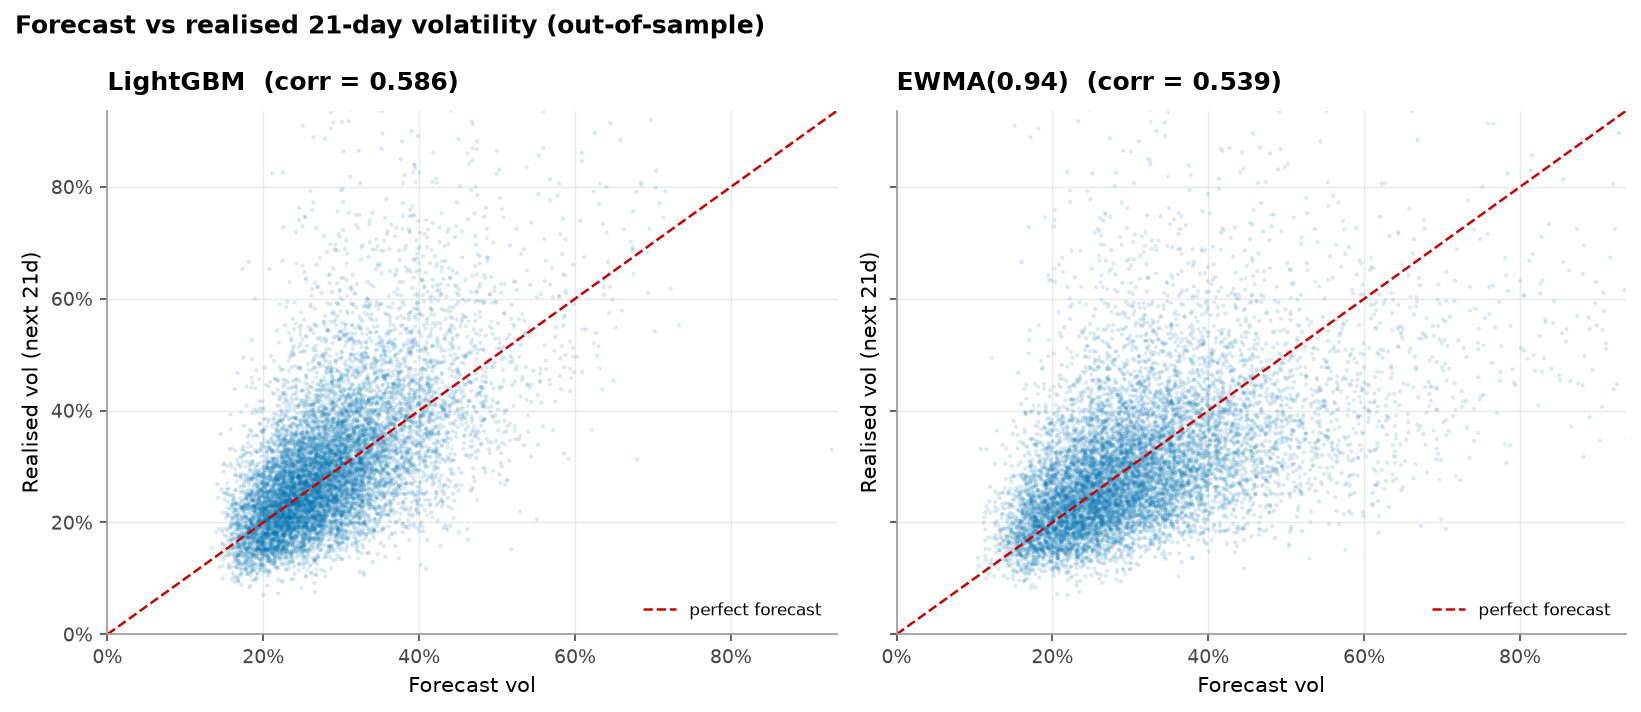

In [10]:
display(Image(filename=str(FIGURES / "vol_pred_vs_actual.png")))


LightGBM beats every baseline on RMSE and QLIKE, and the Diebold-Mariano test confirms the improvement over the random-walk and EWMA baselines is statistically significant (p < 0.001 on both loss functions). Against GARCH(1,1)-t specifically: significant on MSE, but **not** significant on QLIKE (p ≈ 0.16) — reported as-is rather than rounded up to a clean win.

## 5. Does the volatility forecast actually improve the portfolio?

In [11]:
vol_impact = pd.read_csv(TABLES / "vol_forecast_impact.csv", index_col=0)
vol_impact.round(3)


,CAGR,Ann.Vol,Sharpe,Sortino,MaxDD,Calmar,Beta,Alpha,InfoRatio,HitRate,Ann.Return,Ulcer,Skew,Kurtosis,Treynor
min_variance + vol forecast,0.167,0.162,0.644,0.893,-0.305,0.548,0.751,0.053,0.340,0.562,0.168,0.094,-0.770,16.564,0.137
risk_parity + vol forecast,0.208,0.181,0.786,1.069,-0.334,0.622,0.875,0.082,0.743,0.562,0.205,0.095,-1.114,15.761,0.161
min_variance (historical vol),0.186,0.165,0.737,1.025,-0.308,0.605,0.753,0.069,0.488,0.640,0.184,0.094,-0.714,16.726,0.159
risk_parity (historical vol),0.212,0.182,0.802,1.092,-0.333,0.635,0.874,0.085,0.768,0.573,0.209,0.095,-1.095,15.662,0.165


This is the most important honest result in the project. Swapping the covariance diagonal for LightGBM's forecast (`risk.covariance.cov_from_vols`) did **not** uniformly improve the portfolio: min-variance's Sharpe dropped, risk-parity was roughly flat. A better *volatility forecast* is not automatically a better *portfolio input* — the min-variance optimiser reacts to relative differences across stocks and can overweight the effect of the forecast's remaining error in ways the historical estimate didn't. This is reported as a finding, not suppressed because it complicates the "ML made it better" narrative.

## 6. Takeaways

1. Equal-weight is a genuinely hard baseline to beat — consistent with DeMiguel, Garlappi & Uppal (2009) — and only max-Sharpe cleared the bar of statistical significance here.
2. The volatility model is a real, validated improvement in forecasting accuracy (QLIKE, DM-test) that did **not** translate into a portfolio-performance improvement — a useful, common, and underreported result in applied quant work.
3. Universe survivorship bias inflates every strategy's absolute numbers similarly; the strategy-vs-strategy and strategy-vs-equal-weight comparisons are far more trustworthy than any single CAGR.
4. VaR needs backtesting, not just computing — see notebook 02 for where historical VaR's calibration broke down.
